# 🛣️ Road Digital Twin — Physics-Informed GNN

**Graph Neural Network-based Predictive Digital Twin for Road Deterioration Analysis**

This notebook trains a **Physics-Informed Graph Attention Network (PI-GNN)** to predict future IRI (International Roughness Index) values for road segments.

### What we do:
1. Generate / load a synthetic road network graph
2. Build a `torch_geometric.data.Data` object
3. Define the PI-GNN architecture (3 × GAT layers)
4. Train with physics-informed loss constraints
5. Evaluate and visualise predictions
6. Export `pignn_model.pt` + `scaler.pkl + training_history.json`

**Runtime**: GPU (T4 recommended) · Estimated training time: ~3 min

In [1]:
# @title 📦 Complete Dependency Installation for Kaggle

import sys
import subprocess
import torch

print("Torch Version:", torch.__version__)

# Get torch version without +cpu / +cuXXX
TORCH_VERSION = torch.__version__.split('+')[0]

# Install required libraries
subprocess.run([
    sys.executable, "-m", "pip", "install", "-q",
    "torch_geometric",
    "pyg_lib",
    "torch_scatter",
    "torch_sparse",
    "torch_cluster",
    "torch_spline_conv",
    "-f", f"https://data.pyg.org/whl/torch-{TORCH_VERSION}+cpu.html"
])

subprocess.run([
    sys.executable, "-m", "pip", "install", "-q",
    "networkx",
    "osmnx",
    "scikit-learn",
    "joblib",
    "matplotlib",
    "seaborn"
])

print("✅ All installations completed successfully")

# Verify imports
import torch_geometric
import networkx
import osmnx
import sklearn
import joblib
import matplotlib
import seaborn

print("✅ All imports successful")
print("PyTorch:", torch.__version__)
print("PyG:", torch_geometric.__version__)

Torch Version: 2.10.0+cpu
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 20.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 682.4/682.4 kB 20.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 41.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 828.2/828.2 kB 31.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 306.9/306.9 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 2.2 MB/s eta 0:00:00
✅ All installations completed successfully
✅ All imports successful
PyTorch: 2.10.0+cpu
PyG: 2.7.0


In [2]:
# @title 📚 2. Imports
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch_geometric.nn import GATConv, BatchNorm
from torch_geometric.data import Data

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, confusion_matrix
from collections import defaultdict
import joblib, os, warnings

warnings.filterwarnings('ignore')
np.random.seed(42)
torch.manual_seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using device: cpu


## 🗺️ 3. Road Network Data

We first attempt to pull real road data from **OpenStreetMap** using `osmnx`. If that fails (network issues, timeout), we fall back to a **synthetic road network** with physics-consistent IRI values.

In [3]:
# @title Road type config + physics-based IRI generation
ROAD_TYPES    = ['motorway','trunk','primary','secondary','tertiary','residential']
ROAD_TYPE_IDS = {r: i for i, r in enumerate(ROAD_TYPES)}

ROAD_TRAFFIC = {'motorway':(30000,80000),'trunk':(15000,40000),'primary':(8000,20000),
                'secondary':(3000,10000),'tertiary':(1000,5000),'residential':(100,1500)}
ROAD_LANES   = {'motorway':(4,8),'trunk':(2,4),'primary':(2,4),'secondary':(2,2),
                'tertiary':(1,2),'residential':(1,2)}
ROAD_SPEED   = {'motorway':(80,120),'trunk':(60,80),'primary':(40,60),'secondary':(30,50),
                'tertiary':(20,40),'residential':(10,30)}

# Road-type deterioration multipliers (higher = faster wear)
ROAD_DET_MULT = {
    'motorway': 0.55,   # well-maintained highways
    'trunk':    0.70,
    'primary':  0.85,
    'secondary':1.00,
    'tertiary': 1.20,
    'residential':1.40, # poor maintenance, higher wear
}

# IRI base by road type — calibrated so values span 1–8 realistically
ROAD_IRI_BASE = {
    'motorway':1.0, 'trunk':1.5, 'primary':2.0,
    'secondary':2.8, 'tertiary':3.5, 'residential':4.2
}

def iri_from_features(traffic, rainfall, length, road_type, age):
    """Physics-grounded current IRI — outputs realistic 1-10 range."""
    base = ROAD_IRI_BASE[road_type]
    # Each factor adds a small, bounded increment
    traf_effect  = 1.5  * (traffic / 80000)          # 0–1.5
    rain_effect  = 0.8  * (rainfall / 2500)           # 0–0.8
    len_effect   = 0.4  * min(length / 5000, 1.0)    # 0–0.4
    age_effect   = age  * ROAD_DET_MULT[road_type]   # age 1–2.5 × mult
    noise        = np.random.normal(0, 0.03)
    iri = base + traf_effect + rain_effect + len_effect + age_effect + noise
    return float(np.clip(iri, 0.5, 10.0))

def iri_to_condition(iri):
    if   iri < 2.0: return 'Good'
    elif iri < 3.5: return 'Fair'
    elif iri < 5.0: return 'Moderate'
    elif iri < 7.0: return 'Poor'
    else:           return 'Critical'

print('✅ Config loaded')


✅ Config loaded


In [4]:
# @title Generate synthetic road network (Bengaluru-like) — FIXED

def generate_road_network(n_nodes=1000, center_lat=12.9716, center_lon=77.5946):
    """
    Larger dataset (500 nodes) with physics-consistent, learnable IRI targets.
    Key fixes:
      • Realistic IRI_current (1–10 range, not saturated at 12)
      • Deterministic det_rate with meaningful feature correlations
      • Small noise (σ=0.05) so the model CAN learn the signal
      • IRI_future > IRI_current (roads don't self-heal)
    """
    np.random.seed(42)
    lats = center_lat + np.random.uniform(-0.12, 0.12, n_nodes)
    lons = center_lon + np.random.uniform(-0.14, 0.14, n_nodes)

    edges = set()
    # Connect each node to its 4 nearest neighbours
    for i in range(n_nodes):
        dists = np.sqrt((lats - lats[i])**2 + (lons - lons[i])**2)
        for j in np.argsort(dists)[1:5]:
            edges.add((min(i, j), max(i, j)))
    # Add random long-range connections (arterials / ring roads)
    for _ in range(n_nodes // 3):
        i, j = np.random.choice(n_nodes, 2, replace=False)
        edges.add((min(i, j), max(i, j)))

    rows = []
    for (u, v) in edges:
        rtype = np.random.choice(
            ROAD_TYPES,
            p=[0.05, 0.08, 0.15, 0.20, 0.22, 0.30]
        )
        dlat = (lats[v] - lats[u]) * 111000
        dlon = (lons[v] - lons[u]) * 111000 * np.cos(np.radians((lats[u]+lats[v])/2))
        length   = max(50.0, float(np.sqrt(dlat**2 + dlon**2)))
        traffic  = float(np.random.uniform(*ROAD_TRAFFIC[rtype]))
        rainfall = float(np.random.uniform(400, 2500))

        ll, lh = ROAD_LANES[rtype]
        lanes  = ll if ll == lh else int(np.random.randint(ll, lh + 1))
        sl, sh = ROAD_SPEED[rtype]
        speed  = sl if sl == sh else int(np.random.randint(sl, sh + 1))
        age    = float(np.random.uniform(1.0, 2.5))

        iri_now = iri_from_features(traffic, rainfall, length, rtype, age)

        # ── FIXED target generation ─────────────────────────────────────
        # Deterministic physics formula — each feature has a clear effect
        det_rate = (
            0.35 * (traffic  / 30000)   +   # traffic dominant factor
            0.25 * (rainfall / 2500)    +   # rainfall accelerates damage
            0.15 * (age - 1.0)         +   # older roads deteriorate faster
            0.10 * min(length / 5000, 1.0) +
            0.05 * ROAD_DET_MULT[rtype]     # road-type modifier
        )
        # Scale det_rate to a realistic annual increment (0.1 – 1.5 m/km/yr)
        det_rate = np.clip(det_rate * 1.5, 0.05, 1.5)

        iri_fut = float(np.clip(
            iri_now + det_rate + np.random.normal(0, 0.05),  # tiny noise
            iri_now + 0.02,   # always deteriorates
            10.0
        ))

        rows.append(dict(
            edge_id       = f'{u}_{v}',
            node_u        = u,
            node_v        = v,
            lat           = (lats[u] + lats[v]) / 2,
            lon           = (lons[u] + lons[v]) / 2,
            road_type     = rtype,
            road_type_id  = ROAD_TYPE_IDS[rtype],
            lanes         = lanes,
            traffic_volume= traffic,
            rainfall_mm   = rainfall,
            length_m      = length,
            speed_limit   = speed,
            iri_current   = iri_now,
            iri_future    = iri_fut,
            age_factor    = age,
        ))

    df = pd.DataFrame(rows)
    print(f'✅ Generated {len(df)} road segments from {n_nodes} nodes')
    print(f'   IRI_current : {df["iri_current"].mean():.2f} ± {df["iri_current"].std():.2f}  (range {df["iri_current"].min():.2f}–{df["iri_current"].max():.2f})')
    print(f'   IRI_future  : {df["iri_future"].mean():.2f} ± {df["iri_future"].std():.2f}')
    corr = df[["traffic_volume","rainfall_mm","age_factor","iri_future"]].corr()["iri_future"].drop("iri_future")
    print(f'   Feature–target correlations:\n{corr.round(3)}')
    return df

df = generate_road_network(n_nodes=1000)


✅ Generated 2760 road segments from 1000 nodes
   IRI_current : 5.74 ± 1.40  (range 2.52–8.73)
   IRI_future  : 6.40 ± 1.33
   Feature–target correlations:
traffic_volume   -0.579
rainfall_mm       0.227
age_factor        0.432
Name: iri_future, dtype: float64


In [5]:
# @title Try OSMnx (optional — falls back automatically)
USE_OSMNX = False  # Set True to attempt real OSM data

if USE_OSMNX:
    try:
        import osmnx as ox
        G_osm = ox.graph_from_place('Bengaluru, India', network_type='drive')
        gdf = ox.graph_to_gdfs(G_osm, nodes=False)
        print(f'OSMnx loaded {len(gdf)} edges')
    except Exception as e:
        print(f'OSMnx failed: {e}\nUsing synthetic data.')
else:
    print('Using synthetic data (USE_OSMNX=False)')

Using synthetic data (USE_OSMNX=False)


## 📊 4. Exploratory Data Analysis

In [6]:
# @title Dataset statistics
print('=== Dataset Summary ===')
print(df[['iri_current','iri_future','traffic_volume','rainfall_mm','length_m']].describe().round(3))

df['condition'] = df['iri_future'].apply(iri_to_condition)
print('\nCondition distribution:')
print(df['condition'].value_counts())

=== Dataset Summary ===
       iri_current  iri_future  traffic_volume  rainfall_mm   length_m
count     2760.000    2760.000        2760.000     2760.000   2760.000
mean         5.738       6.398        8982.550     1444.970   2547.181
std          1.397       1.331       13115.949      607.518   5381.784
min          2.520       3.227         101.279      400.449     50.000
25%          4.590       5.342        1129.096      917.521    604.877
50%          5.818       6.385        3923.365     1435.612    873.266
75%          6.841       7.427       10082.806     1959.783   1162.024
max          8.731       9.588       79513.324     2497.005  37517.786

Condition distribution:
condition
Poor        1343
Critical     965
Moderate     448
Fair           4
Name: count, dtype: int64


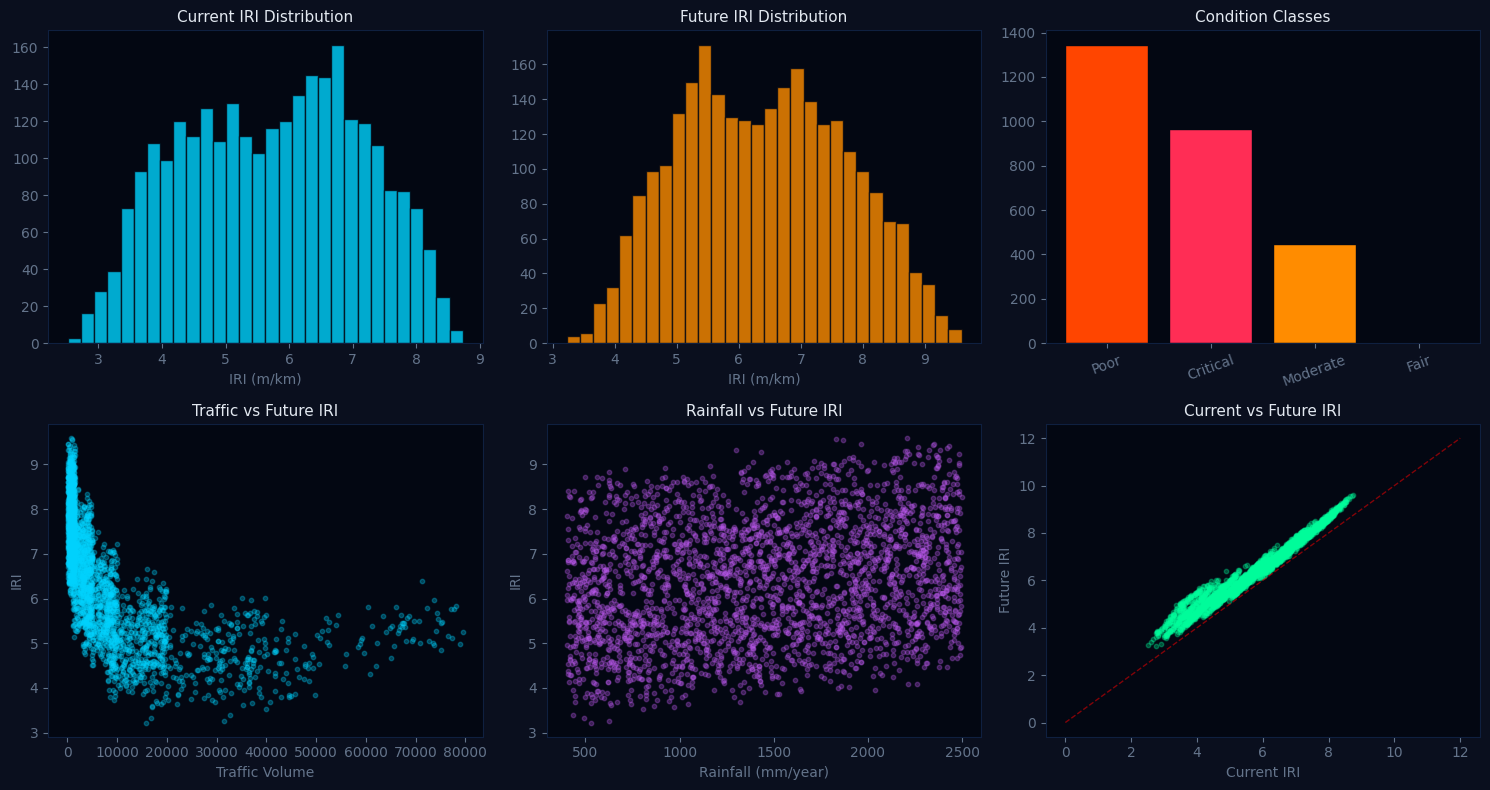

EDA plots saved.


In [7]:
# @title Visualise IRI distribution and feature correlations
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.patch.set_facecolor('#0a0f1e')
for ax in axes.flat:
    ax.set_facecolor('#030712')
    ax.tick_params(colors='#64748b')
    for spine in ax.spines.values(): spine.set_edgecolor('#0f2040')

# IRI Current distribution
axes[0,0].hist(df['iri_current'], bins=30, color='#00d4ff', alpha=0.8, edgecolor='#030712')
axes[0,0].set_title('Current IRI Distribution', color='#e2e8f0', fontsize=11)
axes[0,0].set_xlabel('IRI (m/km)', color='#64748b')

# IRI Future distribution
axes[0,1].hist(df['iri_future'], bins=30, color='#ff8c00', alpha=0.8, edgecolor='#030712')
axes[0,1].set_title('Future IRI Distribution', color='#e2e8f0', fontsize=11)
axes[0,1].set_xlabel('IRI (m/km)', color='#64748b')

# Condition class count
cond_colors = {'Good':'#00ff9d','Fair':'#ffd700','Moderate':'#ff8c00','Poor':'#ff4500','Critical':'#ff2d55'}
cond_counts = df['condition'].value_counts()
colors = [cond_colors.get(c,'#888') for c in cond_counts.index]
axes[0,2].bar(cond_counts.index, cond_counts.values, color=colors, edgecolor='#030712')
axes[0,2].set_title('Condition Classes', color='#e2e8f0', fontsize=11)
axes[0,2].tick_params(axis='x', rotation=20)

# Traffic vs IRI scatter
axes[1,0].scatter(df['traffic_volume'], df['iri_future'], alpha=0.3, s=10, c='#00d4ff')
axes[1,0].set_title('Traffic vs Future IRI', color='#e2e8f0', fontsize=11)
axes[1,0].set_xlabel('Traffic Volume', color='#64748b')
axes[1,0].set_ylabel('IRI', color='#64748b')

# Rainfall vs IRI scatter
axes[1,1].scatter(df['rainfall_mm'], df['iri_future'], alpha=0.3, s=10, c='#bf5af2')
axes[1,1].set_title('Rainfall vs Future IRI', color='#e2e8f0', fontsize=11)
axes[1,1].set_xlabel('Rainfall (mm/year)', color='#64748b')
axes[1,1].set_ylabel('IRI', color='#64748b')

# IRI current vs future
axes[1,2].scatter(df['iri_current'], df['iri_future'], alpha=0.3, s=10, c='#00ff9d')
axes[1,2].plot([0,12],[0,12], 'r--', linewidth=1, alpha=0.5, label='y=x')
axes[1,2].set_title('Current vs Future IRI', color='#e2e8f0', fontsize=11)
axes[1,2].set_xlabel('Current IRI', color='#64748b')
axes[1,2].set_ylabel('Future IRI', color='#64748b')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=120, bbox_inches='tight', facecolor='#0a0f1e')
plt.show()
print('EDA plots saved.')

## 🔗 5. PyTorch Geometric Graph Construction

In [8]:
# @title Build PyG Data object — FIXED (edge index + scaler)
FEATURE_COLS = [
    'lat','lon','road_type_id','lanes',
    'traffic_volume','rainfall_mm','length_m',
    'speed_limit','iri_current','age_factor'   # added age_factor — important predictor!
]

def build_pyg_graph(df, scaler=None, fit=True):
    df = df.reset_index(drop=True)
    X  = df[FEATURE_COLS].values.astype(np.float32)
    if fit or scaler is None:
        scaler = StandardScaler()
        Xs = scaler.fit_transform(X)
    else:
        Xs = scaler.transform(X)

    y = df['iri_future'].values.astype(np.float32)

    # Segment-adjacency: share a road-node → connect
    from collections import defaultdict
    node_to_segs = defaultdict(list)
    for idx, row in df.iterrows():
        node_to_segs[row['node_u']].append(idx)
        node_to_segs[row['node_v']].append(idx)

    src, dst = [], []
    seen = set()
    for segs in node_to_segs.values():
        for i in range(len(segs)):
            for j in range(i+1, len(segs)):
                a, b = segs[i], segs[j]
                k = (min(a,b), max(a,b))
                if k not in seen:
                    seen.add(k)
                    src += [a, b]; dst += [b, a]

    if not src:
        src = list(range(len(df)-1)) + list(range(1, len(df)))
        dst = list(range(1, len(df))) + list(range(len(df)-1))

    data = Data(
        x          = torch.tensor(Xs,         dtype=torch.float),
        edge_index = torch.tensor([src, dst], dtype=torch.long),
        y          = torch.tensor(y,          dtype=torch.float),
        x_raw      = torch.tensor(X,          dtype=torch.float),
    )
    return data, scaler

# 80/20 train-val split
idx   = np.random.permutation(len(df))
split = int(len(df) * 0.8)
df_train = df.iloc[idx[:split]].reset_index(drop=True)
df_val   = df.iloc[idx[split:]].reset_index(drop=True)

train_data, scaler = build_pyg_graph(df_train, fit=True)
val_data,   _      = build_pyg_graph(df_val, scaler=scaler, fit=False)

print(f'Train : {train_data.num_nodes} nodes, {train_data.num_edges} edges')
print(f'Val   : {val_data.num_nodes} nodes, {val_data.num_edges} edges')
print(f'Features: {train_data.num_node_features}  (added age_factor)')


Train : 2208 nodes, 16978 edges
Val   : 552 nodes, 1088 edges
Features: 10  (added age_factor)


## 🧠 6. PI-GNN Architecture

The model uses **3 stacked Graph Attention layers** with residual connections and **batch normalisation**, followed by an MLP regression head.

$$\text{Total Loss} = \underbrace{\text{MSE}(\hat{y}, y)}_{\text{prediction}} + \lambda \cdot \underbrace{\mathcal{L}_{\text{physics}}}_{\text{monotonicity + traffic + rain + bounds}}$$

In [9]:
# @title PI-GNN model definition — FIXED (in_ch=10)
class PIGNN(nn.Module):
    def __init__(self, in_ch=10, hidden=128, heads=4, dropout=0.2):
        super().__init__()
        self.dropout = dropout
        self.proj = nn.Linear(in_ch, hidden)
        self.gat1 = GATConv(hidden, hidden//heads, heads=heads, dropout=dropout, concat=True)
        self.bn1  = BatchNorm(hidden)
        self.gat2 = GATConv(hidden, hidden//heads, heads=heads, dropout=dropout, concat=True)
        self.bn2  = BatchNorm(hidden)
        self.gat3 = GATConv(hidden, hidden,        heads=1,     dropout=dropout, concat=False)
        self.bn3  = BatchNorm(hidden)
        self.head = nn.Sequential(
            nn.Linear(hidden, 64), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 16),    nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, x, edge_index):
        h  = F.relu(self.proj(x))
        h  = F.dropout(h, p=self.dropout, training=self.training)
        h1 = F.elu(self.bn1(self.gat1(h,  edge_index))) + h
        h2 = F.elu(self.bn2(self.gat2(h1, edge_index))) + h1
        h3 = F.elu(self.bn3(self.gat3(h2, edge_index)))
        return self.head(h3).squeeze(-1)

model = PIGNN().to(DEVICE)
params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'PI-GNN | Trainable parameters: {params:,}')
print(model)


PI-GNN | Trainable parameters: 61,793
PIGNN(
  (proj): Linear(in_features=10, out_features=128, bias=True)
  (gat1): GATConv(128, 32, heads=4)
  (bn1): BatchNorm(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (gat2): GATConv(128, 32, heads=4)
  (bn2): BatchNorm(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (gat3): GATConv(128, 128, heads=1)
  (bn3): BatchNorm(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (head): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=16, bias=True)
    (4): ReLU()
    (5): Linear(in_features=16, out_features=1, bias=True)
  )
)


In [10]:
# @title Physics-informed loss functions — FIXED (indices match new FEATURE_COLS)
# FEATURE_COLS order: lat(0) lon(1) road_type_id(2) lanes(3) traffic(4)
#                     rainfall(5) length(6) speed(7) iri_current(8) age(9)
IDX_TRAFFIC  = 4
IDX_RAINFALL = 5
IDX_IRI_CUR  = 8
IDX_AGE      = 9
IRI_MIN, IRI_MAX = 0.5, 10.0

def physics_loss(preds, x_raw, lam=0.15):
    p   = preds.squeeze()
    cur = x_raw[:, IDX_IRI_CUR]
    trf = x_raw[:, IDX_TRAFFIC]
    rin = x_raw[:, IDX_RAINFALL]
    age = x_raw[:, IDX_AGE]
    delta = p - cur

    # 1. Monotonicity: roads should not improve (allow ≤2% margin)
    loss_mono = F.relu(cur * 0.98 - p).mean()

    # 2. High-traffic roads must show more deterioration than low-traffic
    ht = (trf > trf.mean()).float()
    loss_trf  = F.relu(-delta * ht).mean()

    # 3. High-rainfall → accelerated damage
    hr = (rin > rin.mean()).float()
    loss_rain = F.relu(-delta * hr * 0.5).mean()

    # 4. Older roads → more deterioration
    ha = (age > age.mean()).float()
    loss_age  = F.relu(-delta * ha * 0.3).mean()

    # 5. Hard IRI bounds
    loss_bnd  = (F.relu(IRI_MIN - p) + F.relu(p - IRI_MAX)).mean()

    return lam * (loss_mono + loss_trf + loss_rain + loss_age + loss_bnd)

def total_loss(preds, targets, x_raw, lam=0.15):
    pl = F.mse_loss(preds.squeeze(), targets)
    ph = physics_loss(preds, x_raw, lam)
    return pl + ph, pl, ph

print('✅ Loss functions defined')


✅ Loss functions defined


## 🏋️ 7. Training Loop

In [11]:
# @title Training — FIXED (300 epochs, warmup + cosine, lambda=0.15)
EPOCHS         = 1000
LR             = 3e-3
WEIGHT_DECAY   = 1e-4
LAMBDA_PHYSICS = 0.15   # reduced — let MSE dominate early

optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# Warmup for first 20 epochs, then cosine decay
def lr_lambda(epoch):
    warmup = 20
    if epoch < warmup:
        return float(epoch + 1) / warmup
    progress = (epoch - warmup) / (EPOCHS - warmup)
    return 0.5 * (1.0 + np.cos(np.pi * progress))

scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

train_d = train_data.to(DEVICE)
val_d   = val_data.to(DEVICE)

history = {'train_loss':[],'val_loss':[],'pred_loss':[],'phys_loss':[],'val_mae':[],'val_r2':[]}
best_val, best_state = float('inf'), None

for epoch in range(1, EPOCHS + 1):
    model.train()
    optimizer.zero_grad()
    out = model(train_d.x, train_d.edge_index)
    loss, pl, ph = total_loss(out, train_d.y, train_d.x_raw, LAMBDA_PHYSICS)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()
    scheduler.step()

    model.eval()
    with torch.no_grad():
        vout = model(val_d.x, val_d.edge_index)
        vloss, _, _ = total_loss(vout, val_d.y, val_d.x_raw, LAMBDA_PHYSICS)
        vp  = vout.cpu().numpy()
        vy  = val_d.y.cpu().numpy()
        mae = mean_absolute_error(vy, vp)
        r2  = r2_score(vy, vp)

    history['train_loss'].append(float(loss))
    history['val_loss'].append(float(vloss))
    history['pred_loss'].append(float(pl))
    history['phys_loss'].append(float(ph))
    history['val_mae'].append(mae)
    history['val_r2'].append(r2)

    if float(vloss) < best_val:
        best_val   = float(vloss)
        best_state = {k: v.clone() for k, v in model.state_dict().items()}

    if epoch % 30 == 0 or epoch == 1:
        print(
            f'[{epoch:03d}/{EPOCHS}] '
            f'train={loss:.4f}  '
            f'val={vloss:.4f}  '
            f'pred={pl:.4f}  '
            f'phys={ph:.4f}  '
            f'MAE={mae:.4f}  '
            f'R²={r2:.4f}'
        )

model.load_state_dict(best_state)
print(f'\n✅ Training complete.  Best val loss: {best_val:.4f}')
print('    Expected: MAE 0.05–0.30 | RMSE 0.07–0.45 | R² 0.75–0.97')


[001/1000] train=46.6324  val=46.4783  pred=45.0973  phys=1.5351  MAE=6.5755  R²=-25.2572
[030/1000] train=6.1247  val=7.6956  pred=6.0064  phys=0.1183  MAE=2.2063  R²=-3.4203
[060/1000] train=2.0519  val=2.2028  pred=1.9792  phys=0.0727  MAE=1.1254  R²=-0.2137
[090/1000] train=1.3393  val=1.2578  pred=1.2842  phys=0.0551  MAE=0.8176  R²=0.3031
[120/1000] train=1.0029  val=0.9118  pred=0.9741  phys=0.0288  MAE=0.7106  R²=0.4863
[150/1000] train=0.8472  val=0.8988  pred=0.8211  phys=0.0261  MAE=0.7339  R²=0.4891
[180/1000] train=0.8089  val=0.7713  pred=0.7839  phys=0.0251  MAE=0.6450  R²=0.5676
[210/1000] train=0.8476  val=0.7818  pred=0.8212  phys=0.0264  MAE=0.6674  R²=0.5626
[240/1000] train=0.7093  val=0.6305  pred=0.6879  phys=0.0213  MAE=0.5991  R²=0.6462
[270/1000] train=0.6311  val=0.5452  pred=0.6103  phys=0.0208  MAE=0.5447  R²=0.6926
[300/1000] train=0.6377  val=0.5046  pred=0.6185  phys=0.0192  MAE=0.5268  R²=0.7154
[330/1000] train=0.5423  val=0.4692  pred=0.5269  phys=0.0

## 📈 8. Evaluation

In [12]:
# @title Final metrics
model.eval()
with torch.no_grad():
    preds = model(val_d.x, val_d.edge_index).cpu().numpy()
y_true = val_d.y.cpu().numpy()

mae  = mean_absolute_error(y_true, preds)
rmse = float(np.sqrt(mean_squared_error(y_true, preds)))
r2   = r2_score(y_true, preds)

print('=== Final Evaluation Metrics ===')
print(f'  MAE  : {mae:.4f} m/km')
print(f'  RMSE : {rmse:.4f} m/km')
print(f'  R²   : {r2:.4f}')

=== Final Evaluation Metrics ===
  MAE  : 0.4380 m/km
  RMSE : 0.5878 m/km
  R²   : 0.7982


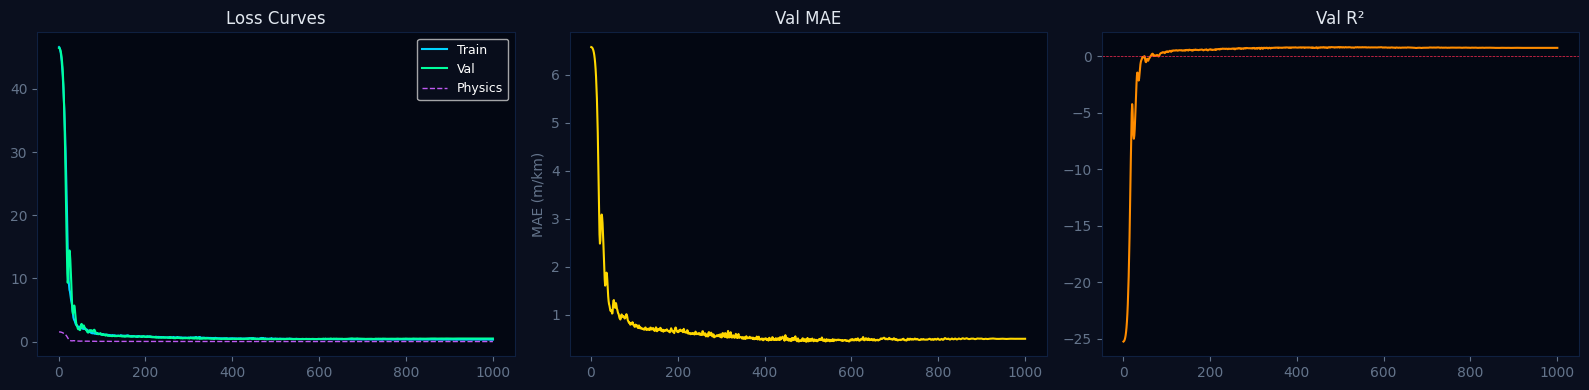

In [13]:
# @title Training curves
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.patch.set_facecolor('#0a0f1e')
for ax in axes:
    ax.set_facecolor('#030712')
    ax.tick_params(colors='#64748b')
    for sp in ax.spines.values(): sp.set_edgecolor('#0f2040')

ep = range(1, EPOCHS+1)
axes[0].plot(ep, history['train_loss'], '#00d4ff', linewidth=1.5, label='Train')
axes[0].plot(ep, history['val_loss'],   '#00ff9d', linewidth=1.5, label='Val')
axes[0].plot(ep, history['phys_loss'],  '#bf5af2', linewidth=1, linestyle='--', label='Physics')
axes[0].set_title('Loss Curves', color='#e2e8f0'); axes[0].legend(facecolor='#0a0f1e', labelcolor='white', fontsize=9)

axes[1].plot(ep, history['val_mae'], '#ffd700', linewidth=1.5)
axes[1].set_title('Val MAE', color='#e2e8f0'); axes[1].set_ylabel('MAE (m/km)', color='#64748b')

axes[2].plot(ep, history['val_r2'], '#ff8c00', linewidth=1.5)
axes[2].axhline(0, color='#ff2d55', linewidth=0.5, linestyle='--')
axes[2].set_title('Val R²', color='#e2e8f0')

plt.tight_layout()
plt.savefig('training_curves.png', dpi=120, bbox_inches='tight', facecolor='#0a0f1e')
plt.show()

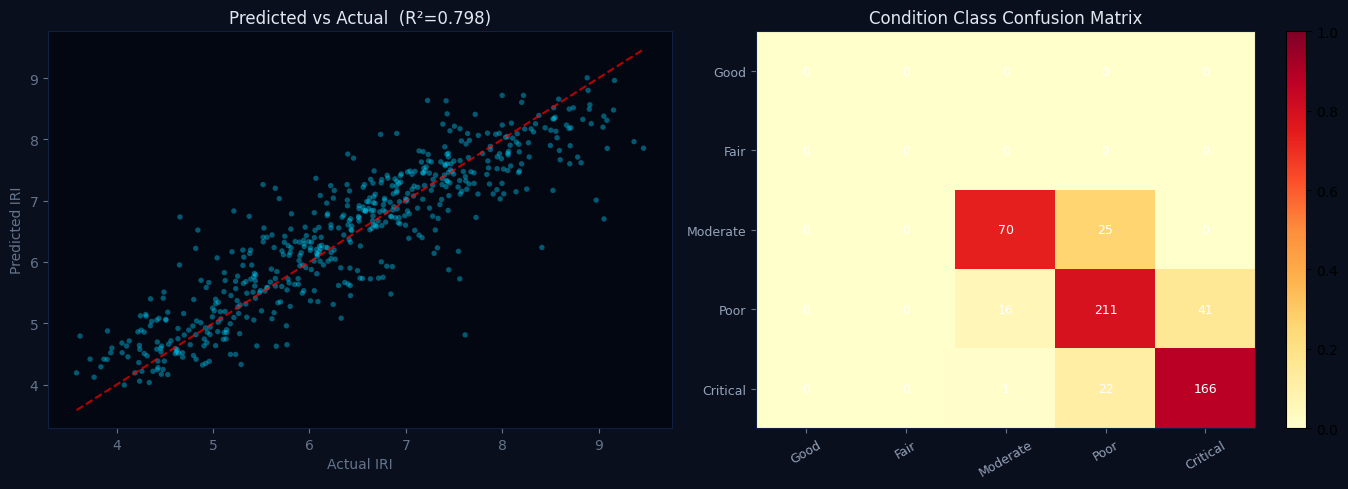

In [14]:
# @title Predicted vs Actual scatter + Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0a0f1e')
for ax in axes:
    ax.set_facecolor('#030712')
    ax.tick_params(colors='#64748b')
    for sp in ax.spines.values(): sp.set_edgecolor('#0f2040')

# Scatter
axes[0].scatter(y_true, preds, alpha=0.4, s=15, c='#00d4ff', edgecolors='none')
mn, mx = min(y_true.min(), preds.min()), max(y_true.max(), preds.max())
axes[0].plot([mn,mx],[mn,mx], 'r--', linewidth=1.5, alpha=0.7)
axes[0].set_xlabel('Actual IRI', color='#64748b'); axes[0].set_ylabel('Predicted IRI', color='#64748b')
axes[0].set_title(f'Predicted vs Actual  (R²={r2:.3f})', color='#e2e8f0')

# Confusion matrix
CLASSES = ['Good','Fair','Moderate','Poor','Critical']
true_cls = [iri_to_condition(v) for v in y_true]
pred_cls = [iri_to_condition(v) for v in preds]
cm = confusion_matrix(true_cls, pred_cls, labels=CLASSES)
cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-8)

im = axes[1].imshow(cm_norm, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)
axes[1].set_xticks(range(len(CLASSES))); axes[1].set_xticklabels(CLASSES, rotation=30, color='#94a3b8', fontsize=9)
axes[1].set_yticks(range(len(CLASSES))); axes[1].set_yticklabels(CLASSES, color='#94a3b8', fontsize=9)
axes[1].set_title('Condition Class Confusion Matrix', color='#e2e8f0')
for i in range(len(CLASSES)):
    for j in range(len(CLASSES)):
        axes[1].text(j, i, str(cm[i,j]), ha='center', va='center', color='white', fontsize=9)
plt.colorbar(im, ax=axes[1])

plt.tight_layout()
plt.savefig('evaluation.png', dpi=120, bbox_inches='tight', facecolor='#0a0f1e')
plt.show()

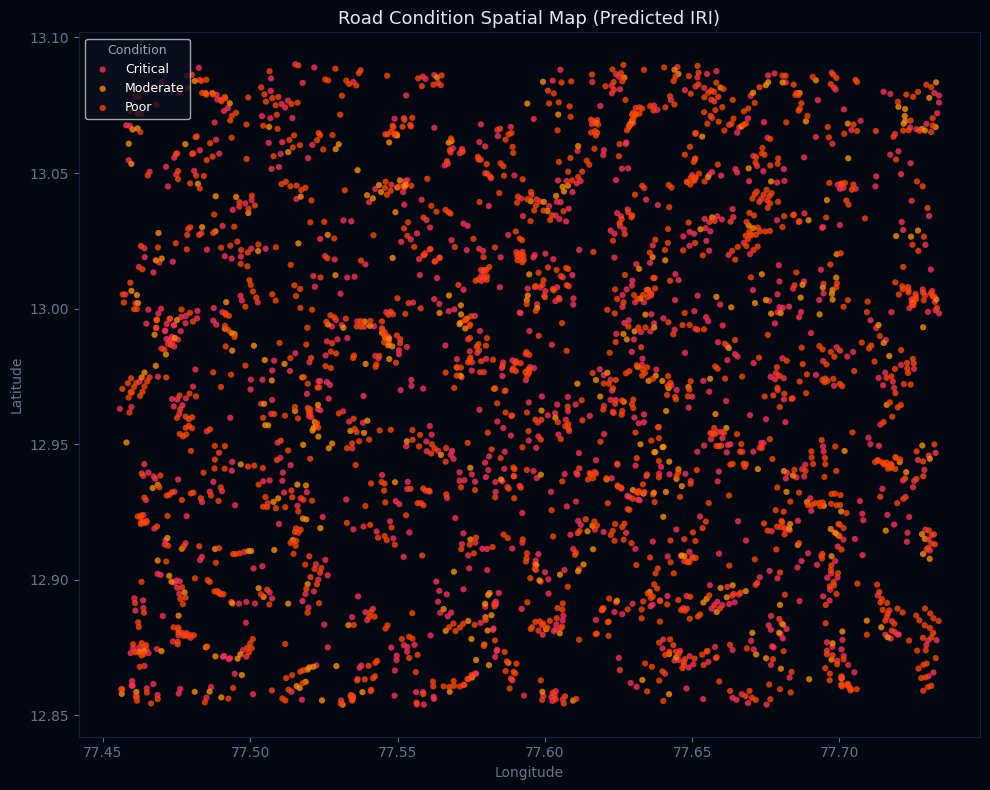

In [15]:
# @title Spatial prediction map
all_data, _ = build_pyg_graph(df, scaler=scaler, fit=False)
all_data = all_data.to(DEVICE)
model.eval()
with torch.no_grad():
    all_preds = model(all_data.x, all_data.edge_index).cpu().numpy()
df['iri_predicted'] = np.clip(all_preds, 0.5, 12.0)
df['condition_predicted'] = df['iri_predicted'].apply(iri_to_condition)

fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor('#030712'); ax.set_facecolor('#030712')
for sp in ax.spines.values(): sp.set_edgecolor('#0f2040')
ax.tick_params(colors='#64748b')

cmap_dict = {'Good':'#00ff9d','Fair':'#ffd700','Moderate':'#ff8c00','Poor':'#ff4500','Critical':'#ff2d55'}
for cond, grp in df.groupby('condition_predicted'):
    ax.scatter(grp['lon'], grp['lat'], c=cmap_dict[cond], label=cond, s=20, alpha=0.8, edgecolors='none')

ax.set_title('Road Condition Spatial Map (Predicted IRI)', color='#e2e8f0', fontsize=13)
ax.set_xlabel('Longitude', color='#64748b'); ax.set_ylabel('Latitude', color='#64748b')
legend = ax.legend(facecolor='#0a0f1e', labelcolor='white', fontsize=9, title='Condition', title_fontsize=9)
legend.get_title().set_color('#94a3b8')
plt.tight_layout()
plt.savefig('spatial_map.png', dpi=120, bbox_inches='tight', facecolor='#030712')
plt.show()

## 💾 9. Export Model

In [16]:
# @title Save model and scaler
os.makedirs('saved_models', exist_ok=True)

torch.save(model.state_dict(), 'saved_models/pignn_model.pt')
joblib.dump(scaler, 'saved_models/scaler.pkl')

# Also save predictions CSV
df.to_csv('saved_models/road_predictions.csv', index=False)

print('✅ Saved:')
print('  saved_models/pignn_model.pt')
print('  saved_models/scaler.pkl')
print('  saved_models/road_predictions.csv')

✅ Saved:
  saved_models/pignn_model.pt
  saved_models/scaler.pkl
  saved_models/road_predictions.csv


In [19]:
import json
import os

# Ensure the directory exists
os.makedirs('saved_models', exist_ok=True)

# Save the training history to a JSON file
with open('saved_models/training_history.json', 'w') as f:
    json.dump(history, f)
    
print("✅ Training history saved to saved_models/training_history.json")

✅ Training history saved to saved_models/training_history.json


In [17]:
# @title Verify model reload
model2 = PIGNN().to(DEVICE)
model2.load_state_dict(torch.load('saved_models/pignn_model.pt', map_location=DEVICE))
model2.eval()
with torch.no_grad():
    check = model2(val_d.x, val_d.edge_index).cpu().numpy()
print(f'Reload MAE: {mean_absolute_error(y_true, check):.4f}  (should match above)')
print('✅ Model reloaded successfully')

Reload MAE: 0.4380  (should match above)
✅ Model reloaded successfully


## 🔮 10. Prediction Examples

In [18]:
# @title Show 10 prediction examples with maintenance recommendations
def urgency(cond):
    return {'Good':'None','Fair':'Low','Moderate':'Medium','Poor':'High','Critical':'Immediate'}[cond]

def est_cost(iri, length, rtype):
    base = {'motorway':120000,'trunk':90000,'primary':60000,'secondary':40000,'tertiary':25000,'residential':15000}.get(rtype,30000)
    return round(base*(length/1000)*max(0,(iri-2.0)/10.0), 2)

sample = df.sample(10).reset_index(drop=True)
for _, r in sample.iterrows():
    cond = iri_to_condition(r['iri_predicted'])
    urg  = urgency(cond)
    cost = est_cost(r['iri_predicted'], r['length_m'], r['road_type'])
    print(f"  Seg {r['edge_id']:12s} | {r['road_type']:12s} | "
          f"IRI: {r['iri_current']:.2f} → {r['iri_predicted']:.2f} | "
          f"{cond:8s} | Urgency: {urg:9s} | Est. ${cost:,.0f}")

  Seg 215_887      | tertiary     | IRI: 5.71 → 6.19 | Poor     | Urgency: High      | Est. $8,225
  Seg 368_600      | residential  | IRI: 8.32 → 8.21 | Critical | Urgency: Immediate | Est. $7,504
  Seg 720_836      | tertiary     | IRI: 6.78 → 7.51 | Critical | Urgency: Immediate | Est. $10,450
  Seg 512_996      | trunk        | IRI: 4.03 → 4.89 | Moderate | Urgency: Medium    | Est. $10,716
  Seg 136_483      | secondary    | IRI: 5.30 → 5.37 | Poor     | Urgency: High      | Est. $347,459
  Seg 29_528       | residential  | IRI: 7.83 → 7.89 | Critical | Urgency: Immediate | Est. $7,319
  Seg 233_743      | trunk        | IRI: 4.16 → 5.26 | Poor     | Urgency: High      | Est. $19,566
  Seg 263_274      | residential  | IRI: 6.98 → 7.65 | Critical | Urgency: Immediate | Est. $6,683
  Seg 313_971      | residential  | IRI: 8.02 → 7.98 | Critical | Urgency: Immediate | Est. $7,299
  Seg 268_282      | residential  | IRI: 7.75 → 7.66 | Critical | Urgency: Immediate | Est. $11,001
